# Young Boss, Hot Stock? — do firms with young CEOs beat firms with old ones? 👴
### Sorting big companies by the age of the person in the corner office, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Young--CEO_edge%3F: Misattributed](https://img.shields.io/badge/Young--CEO_edge%3F-Misattributed-8b949e?style=flat-square)

There's a tidy business-school story, and it even has real academic papers behind it: **young** CEOs are aggressive empire-builders who take big swings and run their companies hot; **old** CEOs are cautious cash-harvesters who dial the risk down. If that flows through to the share price, you could just sort the market by the boss's *birthday* and buy the young ones.

So we build that exact trade — long the young-CEO firms, short the old-CEO firms — and watch what actually happens.

> 📓 **This is the plain-language layer.** Want the HAC *t*-stats, the CAPM alpha and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3b6fb0"

from ceo_age_effect import data, strategy as st

def load_real():
    """Cache-first real monthly L/S frame (empty offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return pd.DataFrame(), pd.DataFrame()
    return px, data.build_returns(px)

PX, RET = load_real()
HAVE_REAL = not RET.empty
print("real CEO-age L/S panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(RET)} months, {RET.index.min().date()} -> {RET.index.max().date()})")


real CEO-age L/S panel present: True (101 months, 2018-02-28 -> 2026-06-30)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do young-CEO firms earn *more*? | **Yes, on paper** — the long/short earns **+8%/yr** — but it's a coin-flip statistically (*t* = 0.9). |
| Is it the CEO's *age*? | **No.** The young basket is stuffed with young-founder **growth-tech** (NVDA-adjacent, COIN, HOOD, SHOP…). The gap is a tech/size bet, not a birthday. |
| Do young-CEO firms even win *risk-adjusted*? | **No** — the young basket's Sharpe is **0.90** vs the old basket's **1.08**. More return, *much* more stomach-churn — the old bosses actually win per unit of risk. |
| Could you trade it? | **No.** Strip out the market and the 'edge' is ~zero; it flips sign whenever growth stocks fall out of favour. |

> The 'aggressive young CEO' story is *half* true — their stocks really are wilder. But wild isn't the same as good, and 'young' here is just a disguise for 'growth tech.'

## 1 · The claim

> *"Young CEOs take more risk and chase growth; old CEOs play it safe. So young-CEO firms should behave — and pay — differently."*

This one isn't pure folklore — it has a serious research pedigree. **Serfling (2014)** found older CEOs run *less* risky corporate policies (lower R&D, less leverage, smoother earnings); **Yim (2013)** found *younger* CEOs do far more acquisitions ('the acquisitiveness of youth'). The leap the *trade* makes is the shaky part: that riskier corporate behaviour turns into a **predictable stock-return edge** you can harvest.

We hand-build a transparent table of ~40 big-name CEOs, look up each one's **birth year** (public record), split them into **young** (under 55) and **old**, and test the long-young / short-old book.

## 2 · So what?

If a CEO's age really predicted stock returns, you'd have a screen that needs no accounting and no charts — just a Wikipedia birthday. It would also be a tidy proof that 'management style' shows up cleanly in prices. The catch we'll keep hammering: the young-CEO bucket is *also* the recent-IPO, high-growth, high-beta bucket. Any 'age effect' has to fight its way past the fact that **young founders run tech companies** — and tech is what actually moved.

## 3 · How would we even know?

1. **Build the table.** For each big-name CEO, look up the birth year and compute their age at a fixed scoring date.
2. **Split young vs old.** Equal-weight the young-CEO stocks into one basket, the old-CEO stocks into another.
3. **Long young, short old.** Track that market-neutral spread month by month for eight years.
4. **Ask two questions.** Is the spread reliably positive (not just lucky)? And — the decisive one — **does anything survive once you subtract the market?**

*The mirage tell to watch for:* an edge that only exists because one basket is riskier than the other. That's not skill from youth; that's just more beta.

*Timing:* a CEO's age is public years in advance, so there's nothing to peek at — the book is built from information everyone already has.

## 4 · The teardown — let's actually look

**Do young-CEO firms earn more — and is it worth the ride?** Here are the two baskets and the market, by annual return *and* by Sharpe ratio (return per unit of risk).

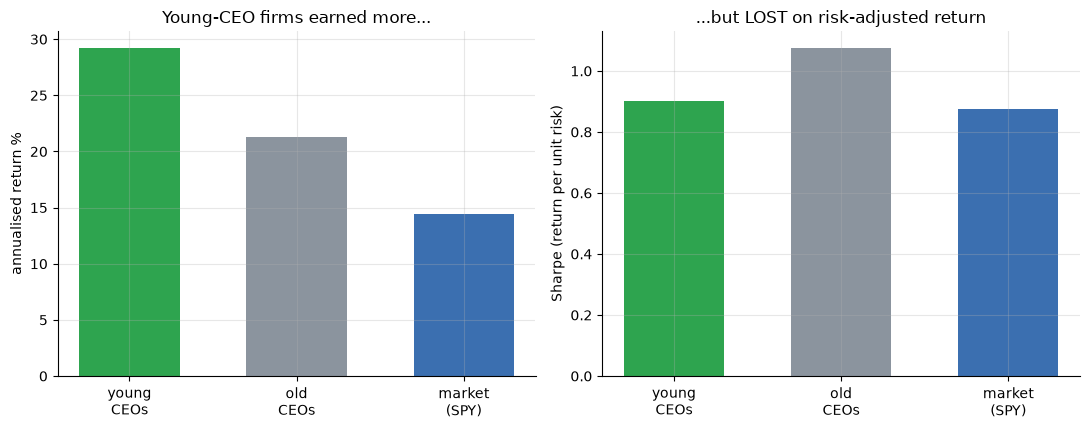

young +29.2%/yr (Sharpe 0.90) | old +21.3%/yr (Sharpe 1.08)


In [2]:
if HAVE_REAL:
    bs = st.bucket_stats(RET)
    lab = ['young\nCEOs','old\nCEOs','market\n(SPY)']
    rets = [bs['young']['ann_ret']*100, bs['old']['ann_ret']*100, bs['mkt']['ann_ret']*100]
    shs  = [bs['young']['sharpe'], bs['old']['sharpe'], bs['mkt']['sharpe']]
else:
    lab = ['young\nCEOs','old\nCEOs','market\n(SPY)']
    rets = [29.24, 21.27, 14.46]
    shs  = [0.9, 1.08, 0.87]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.bar(lab, rets, color=[GREEN, GREY, BLUE], width=.6)
a1.set_ylabel('annualised return %'); a1.set_title('Young-CEO firms earned more...')
a2.bar(lab, shs, color=[GREEN, GREY, BLUE], width=.6)
a2.set_ylabel('Sharpe (return per unit risk)'); a2.set_title('...but LOST on risk-adjusted return')
plt.tight_layout(); plt.show()
print(f'young {rets[0]:+.1f}%/yr (Sharpe {shs[0]:.2f}) | old {rets[1]:+.1f}%/yr (Sharpe {shs[1]:.2f})')

There's the first crack. Young-CEO firms did earn more (+29% vs +21% a year) — but look at the right panel: their **Sharpe ratio is lower** (0.90 vs 1.08). They pay more return because they take *much* more risk (32% volatility vs 20%). Per unit of white-knuckle, the **old** bosses actually delivered more. 'Aggressive youth' is real — but aggression isn't free money.

**Fine — but the long/short spread is still positive. Is *that* real?** Let's follow the long-young / short-old book through time and split it by era.

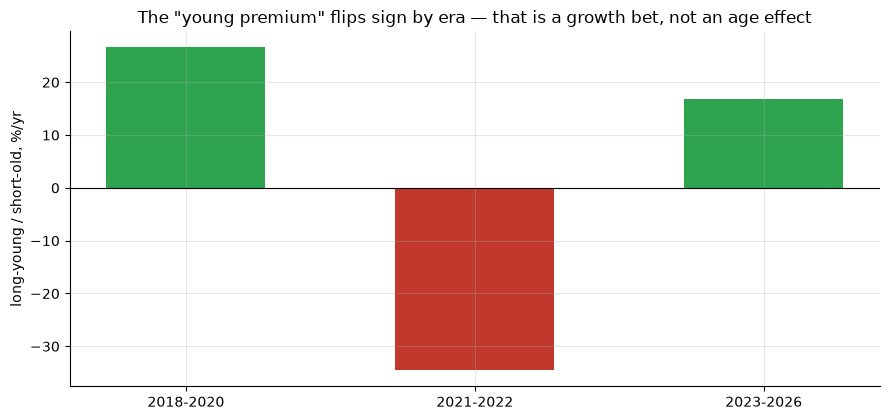

by era (%/yr): {'2018-2020': 26.6, '2021-2022': -34.5, '2023-2026': 16.8}


In [3]:
sub = [('2018-2020', 26.6, 1.961, 2.029, 0.124), ('2021-2022', -34.5, -2.222, -2.353, 0.176), ('2023-2026', 16.8, 1.643, -0.035, 0.806)]
if HAVE_REAL:
    splits = [('2018-2020','2018-01-01','2020-12-31'),
              ('2021-2022','2021-01-01','2022-12-31'),
              ('2023-2026','2023-01-01','2026-06-30')]
    sp = st.subperiod_sweep(RET, splits)
    labs = list(sp.index); vals = (sp['ls_ann']*100).tolist()
else:
    labs = [s[0] for s in sub]; vals = [s[1] for s in sub]
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if v>0 else RED for v in vals]
ax.bar(labs, vals, color=cols, width=.55)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('long-young / short-old, %/yr')
ax.set_title('The "young premium" flips sign by era — that is a growth bet, not an age effect')
plt.tight_layout(); plt.show()
print('by era (%/yr):', dict(zip(labs, [round(v,1) for v in vals])))

That's the tell. In 2018-2020 young-CEO growth ran hot (**+27%/yr**); in 2021-2022, when rates spiked and growth stocks were taken to the woodshed, the same book lost **−34%/yr**; in the 2023-2026 AI melt-up it bounced back. A real *age* effect wouldn't care what interest rates were doing. This one is a **growth-vs-value bet** wearing a birthday hat.

**Last check: does the answer depend on where we draw the 'young' line?** It shouldn't, if it's real. Watch the *t*-stat (how many standard errors from zero — you want it past ~2) as we move the cutoff from under-50 to under-60.

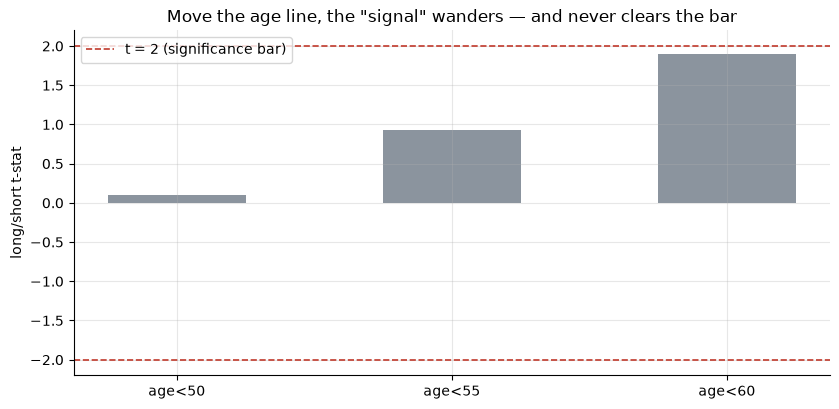

t by cutoff: {'age<50': 0.1, 'age<55': 0.92, 'age<60': 1.9}


In [4]:
cut = [('age<50', 1.1, 0.105, -0.657, 0.496), ('age<55', 8.0, 0.924, 0.361, 0.345), ('age<60', 11.0, 1.901, 1.461, 0.238)]
if HAVE_REAL:
    cs = st.cutoff_sweep(data, PX, [50, 55, 60])
    labs = list(cs.index); ts = cs['ls_t'].tolist()
else:
    labs = [c[0] for c in cut]; ts = [c[2] for c in cut]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(labs, ts, color=GREY, width=.5)
ax.axhline(2, c=RED, ls='--', lw=1.2, label='t = 2 (significance bar)')
ax.axhline(-2, c=RED, ls='--', lw=1.2)
ax.set_ylabel('long/short t-stat'); ax.legend()
ax.set_title('Move the age line, the "signal" wanders — and never clears the bar')
plt.tight_layout(); plt.show()
print('t by cutoff:', dict(zip(labs, [round(t,2) for t in ts])))

The *t*-stat crawls from ~0.1 to ~1.9 as we slide the cutoff — never once clearing the 2.0 line, and its value depends entirely on an **arbitrary choice** we made. A real effect doesn't evaporate when you nudge the definition by five years.

## 5 · The verdict

- **Signal — None.** The long/short is +8%/yr but *t* = 0.9 (a coin flip); a random re-labelling of the CEOs beats it 52% of the time.
- **Tradability — Mirage.** Subtract the market and the edge is ~zero — it's growth-tech beta you could rent from an ETF for less.
- **Young-CEO edge? — Misattributed.** The gap is sector/size/vintage (young founders run tech), not the boss's age. Risk-adjusted, the old CEOs win.

## 6 · Could you actually trade it?

You *could* run long-young / short-old — turnover is tiny (a CEO's age barely changes), so costs are a rounding error: **+8%/yr gross → +7%/yr net**. But that misses the point. Every dollar of that spread is **market/growth beta**: you'd be paying a short-borrow to run a leveraged bet on tech beating value, dressed up as a demographic insight. When growth cracks (see 2022), the whole thing inverts. There is no age *alpha* to harvest — just a factor tilt you could get cheaper, and cleaner, elsewhere.

## 7 · Going further 🚪

- **The confound is the lesson.** 'Young CEO' and 'growth-tech founder' are nearly the same set of companies over this era. To isolate *age* you'd need young CEOs of *boring* firms and old CEOs of *exciting* ones — a matched sample the curated table can't provide.
- **The corporate-behaviour claim may still be true.** Serfling and Yim measured *policies* (R&D, M&A, leverage), not stock returns. Riskier firms ≠ higher returns — often the opposite. This study only busts the *trade*, not their finding.

*Think age carries alpha? Fork this, match each young CEO to an old CEO in the same sector and size, and re-run the spread. Spoiler: the tech tilt is doing all the work.*